In [178]:
import pandas as pd
scores = pd.read_csv("results_scored.csv")

### Data Cleaning 
There were a lot of rowsa that came in a duplicates. Herewe are fixing that to ensure that we are seeing only one record for each Query, Method, and Rank combination.  

In [179]:
scores_clean = scores.drop_duplicates(
    subset=[
        "Query",
        "Method",
        "Rank",
        "Similarity Score (%)",
        "Text",
        "Psalm Num",
        "Verse",
        "Letter"
    ],
    keep="first"
)

scores = scores_clean
print(scores.shape)

scores[scores['Query'] == 'struggle'].drop_duplicates()

(1610, 10)


,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0
33,struggle,BERT,5,30.93,Psalter,1,Blessed is the man that hath not walked in the...,False,A,0
34,struggle,SBERT,5,95.96,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,B,1
406,struggle,BERT,2,34.15,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",False,A,1
407,struggle,SBERT,2,96.15,Psalter,149,"Sing unto the Lord a new song, His praise is i...",False,B,0
1653,struggle,BERT,1,35.08,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,A,0
1654,struggle,SBERT,1,96.24,Psalter,150,Praise God in His holy ones; praise Him in the...,False,B,1
1655,struggle,TF-IDF,1,0.00,Psalter,150,Praise God in His holy ones; praise Him in the...,False,C,2
2115,struggle,BERT,3,31.66,Bible,18,For the End a psalm by David The heavens decla...,False,A,1


## Missing result Imputation and Score Rellocation
Algorithm
----
1. groupby 'Query' and 'Rank"
2. check if all four methods are recorded
    - 'BERT', 'SBERT', 'TF-IDF + GloVe', 'TF-IDF'
    - record the number of missing methods
3. if there is at least one method not being represented
    1. add rows for the missing methods with giving the score as 1
    2. increase the other method's score with the number of previously missing methods
    3. ensure thatno method has a score higher than 3
5. save to a new Dataframe 

In [180]:
import pandas as pd

EXPECTED_METHODS = {
    "BERT",
    "SBERT",
    "TF-IDF + GloVe",
    "TF-IDF"
}

new_groups = []
augmented_scores = pd.DataFrame()

for (query, rank), group in scores.groupby(["Query", "Rank"]):

    group = group.copy()

    # Mark original rows
    group["Imputed"] = False

    present_methods = set(group["Method"])
    missing_methods = EXPECTED_METHODS - present_methods
    n_missing = len(missing_methods)

    if n_missing > 0:

        # Increase existing scores
        group["Score"] = (group["Score"] + n_missing).clip(upper=3)

        for method in missing_methods:

            new_row = {col: pd.NA for col in scores.columns}

            # Required fields
            new_row["Query"] = query
            new_row["Rank"] = rank
            new_row["Method"] = method
            new_row["Score"] = 1

            # Explicitly null out retrieval data
            new_row["Similarity Score (%)"] = pd.NA
            new_row["Text"] = pd.NA
            new_row["Psalm Num"] = pd.NA
            new_row["Verse"] = pd.NA
            new_row["Scored"] = pd.NA
            new_row["Letter"] = pd.NA

            new_row["Imputed"] = True

            group = pd.concat(
                [group, pd.DataFrame([new_row])],
                ignore_index=True
            )

    new_groups.append(group)

augmented_scores = pd.concat(new_groups, ignore_index=True)

# Verification
print(
    augmented_scores
    .groupby(["Query", "Rank"])["Method"]
    .nunique()
    .value_counts()
)

print(
    augmented_scores["Imputed"]
    .value_counts()
)

Method
4    420
Name: count, dtype: int64
Imputed
False    1610
True       70
Name: count, dtype: int64


In [181]:
augmented_scores[augmented_scores["Query"] == 'struggle']

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Imputed
1600,struggle,BERT,1,35.08,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,A,1,False
1601,struggle,SBERT,1,96.24,Psalter,150,Praise God in His holy ones; praise Him in the...,False,B,2,False
1602,struggle,TF-IDF,1,0.0,Psalter,150,Praise God in His holy ones; praise Him in the...,False,C,3,False
1603,struggle,TF-IDF + GloVe,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,True
1604,struggle,BERT,2,34.15,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",False,A,3,False
1605,struggle,SBERT,2,96.15,Psalter,149,"Sing unto the Lord a new song, His praise is i...",False,B,2,False
1606,struggle,TF-IDF + GloVe,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,True
1607,struggle,TF-IDF,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,True
1608,struggle,BERT,3,31.66,Bible,18,For the End a psalm by David The heavens decla...,False,A,3,False
1609,struggle,SBERT,3,96.1,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...",False,B,2,False


In [182]:
query = "struggle"

orig = scores[scores["Query"] == query]
aug = augmented_scores[augmented_scores["Query"] == query]

print(f"Query: '{query}'")
print("-" * 40)
print(f"Original rows:              {len(orig)}")
print(f"Original unique rows:       {len(orig.drop_duplicates())}")
print(f"Original duplicates:        {len(orig) - len(orig.drop_duplicates())}")
print()
print(f"Augmented rows:             {len(aug)}")
print(f"Augmented unique rows:      {len(aug.drop_duplicates())}")
print(f"Augmented duplicates:       {len(aug) - len(aug.drop_duplicates())}")

Query: 'struggle'
----------------------------------------
Original rows:              11
Original unique rows:       11
Original duplicates:        0

Augmented rows:             20
Augmented unique rows:      20
Augmented duplicates:       0


In [171]:
# Saving new Data as scores
scores = augmented_scores

============================================

# Evaluation

In [183]:
# before giving the results in a random Order
pd.pivot_table(
    data=scores,
    values='Query',
    index=['Method'],
    columns='Score',
    aggfunc='count',
    fill_value=0
)

Score,0,1,2,3
Method,,,,
BERT,93,129,93,103
SBERT,107,95,119,84
TF-IDF,151,85,108,48
TF-IDF + GloVe,69,108,79,139


In [184]:
from scipy.stats import chi2_contingency

#scores = scores.tail(20)

table = pd.crosstab(
    scores["Letter"],
    scores["Score"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 88.28105347676973
p-value: 3.600012920235355e-15


$$ P_{value} =  9.81 × 10⁻²⁷$$
which is extremely small.
That means the score distributions are very unlikely to be the same across methods by random chance alone.

Previous stats: 
* Chi-square: 176.106
* p-value: 3.29e-33

### Cramer's V

Cramer's V is a measure of the strength of association between two categorical variables. Unlike a p-value, which tells you whether an effect is likely real, Cramer's V tells you how large the effect is.

### Guidelines for Interpreting Cramer's V

| Cramer's V | Interpretation |
|------------|---------------|
| < 0.10 | Negligible effect |
| 0.10 – 0.29 | Small effect |
| 0.30 – 0.49 | Medium effect |
| ≥ 0.50 | Large effect |

**Note:** Cramer's V ranges from 0 to 1, where 0 indicates no association and 1 indicates a perfect association between categorical variables.

In [185]:
from scipy.stats import chi2_contingency
import numpy as np

table = pd.crosstab(
    scores["Letter"],
    scores["Score"]
)

chi2, p, _, _ = chi2_contingency(table)

n = table.sum().sum()
r, k = table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r-1, k-1))
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.13519486241476697


### Why Cramer's V Was Preferred Over the p-value

- The p-value only indicates whether a statistically significant difference exists; it does not measure the magnitude of that difference.

- The p-value is highly sensitive to sample size. With a sufficiently large number of LLM evaluations, even trivial differences between retrieval methods may produce very small p-values.

- A significant p-value does not imply that the observed differences are practically meaningful for retrieval performance.

- Cramer's V provides a standardized measure of effect size, quantifying the strength of the association between retrieval method and LLM-assigned relevance scores.

- Unlike the p-value, Cramer's V allows the practical significance of differences between retrieval methods to be assessed and compared across experiments.

- Because the objective of this study is to evaluate the impact of retrieval methods on relevance scoring, effect size measurements such as Cramer's V are more informative than significance testing alone.

In [195]:
comparisons = pd.read_csv("method_comparisons.csv")
comparisons.head(10)

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
0,struggle,4,BERT,B,SBERT,A,BERT
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
4,creation,2,SBERT,X,BERT,Y,SBERT
5,creation,2,BERT,A,TF-IDF,B,BERT
6,creation,2,TF-IDF,Y,SBERT,X,SBERT
7,"Ye hold matrys, who foughts the good fight and...",1,TF-IDF + GloVe,B,BERT,A,BERT
8,"Ye hold matrys, who foughts the good fight and...",1,SBERT,X,TF-IDF + GloVe,Y,SBERT
9,"Ye hold matrys, who foughts the good fight and...",1,TF-IDF + GloVe,A,TF-IDF,B,TF-IDF + GloVe


In [193]:
comparisons.tail(10)

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
14720,Have Mercy on me,3,TF-IDF + GloVe,X,TF-IDF,Y,TF-IDF + GloVe
14721,Have Mercy on me,3,BERT,X,SBERT,Y,BERT
14722,Have Mercy on me,3,BERT,X,TF-IDF,Y,BERT
14723,Have Mercy on me,3,TF-IDF,X,SBERT,Y,TF-IDF
14724,Because of the distress of ther beggars and th...,2,BERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe
14725,Because of the distress of ther beggars and th...,2,SBERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe
14726,Because of the distress of ther beggars and th...,2,TF-IDF,A,TF-IDF + GloVe,B,TF-IDF
14727,Because of the distress of ther beggars and th...,2,SBERT,Y,BERT,X,BERT
14728,Because of the distress of ther beggars and th...,2,TF-IDF,A,BERT,B,TF-IDF
14729,Because of the distress of ther beggars and th...,2,TF-IDF,A,SBERT,B,TF-IDF


In [187]:
comparisons[['Query', 'Rank']].drop_duplicates().shape[0]

417

# Looking at different frequencies

In [10]:
pd.crosstab(comparisons["Method_A"], comparisons["Method_A_letter"])

Method_A_letter,A,B,X,Y
Method_A,,,,
BERT,1007,1002,990,946
SBERT,926,907,949,863
TF-IDF,965,898,904,899
TF-IDF + GloVe,864,891,881,838


In [11]:
comparisons = comparisons.loc[:, ~comparisons.columns.duplicated()]

In [ ]:
method_letter_counts = pd.crosstab(
    comparisons["Method_A"],
    comparisons["Method_A_letter"],
)

method_letter_pct = (
    method_letter_counts.div(method_letter_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

summary_A = pd.concat(
    [method_letter_counts, method_letter_pct],
    axis=1,
    keys=["count", "percent"],
)


In [98]:


method_B_letter_counts = pd.crosstab(
    comparisons["Method_B"],
    comparisons["Method_B_letter"],
)

method_B_letter_pct = (
    method_B_letter_counts.div(method_B_letter_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

summary_B = pd.concat(
    [method_B_letter_counts, method_B_letter_pct],
    axis=1,
    keys=["count", "percent"],
)

In [14]:
print("Summary of Method A")
display(summary_A)

print("Summary of Method B")
display(summary_B)

Summary of Method A


count                 percent                     
Method_A_letter     A     B    X    Y       A      B      X      Y
Method_A                                                          
BERT             1007  1002  990  946   25.53  25.40  25.10  23.98
SBERT             926   907  949  863   25.40  24.88  26.04  23.68
TF-IDF            965   898  904  899   26.32  24.50  24.66  24.52
TF-IDF + GloVe    864   891  881  838   24.87  25.65  25.36  24.12

Summary of Method B


count                percent                     
Method_B_letter     A    B    X    Y       A      B      X      Y
Method_B                                                         
BERT              963  975  910  951   25.35  25.66  23.95  25.03
SBERT             932  923  896  904   25.50  25.25  24.51  24.73
TF-IDF            836  925  848  887   23.91  26.46  24.26  25.37
TF-IDF + GloVe    967  939  892  982   25.58  24.84  23.60  25.98

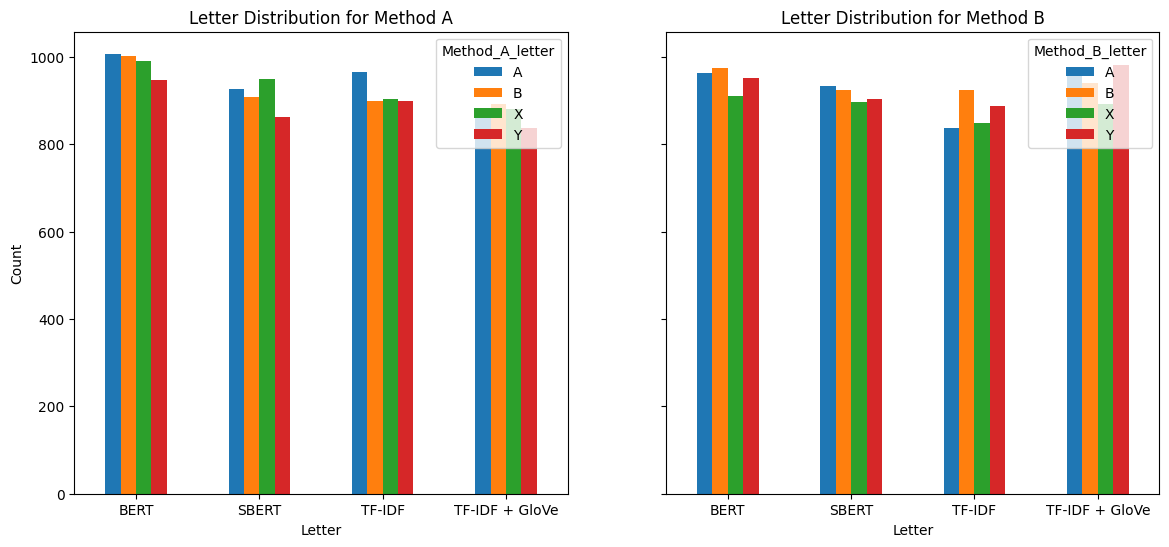

In [15]:
import matplotlib.pyplot as plt
# Extract count data
counts_A = summary_A['count']
counts_B = summary_B['count']

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Method A
counts_A.plot(kind='bar', ax=axes[0])
axes[0].set_title("Letter Distribution for Method A")
axes[0].set_xlabel("Letter")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Method B
counts_B.plot(kind='bar', ax=axes[1])
axes[1].set_title("Letter Distribution for Method B")
axes[1].set_xlabel("Letter")
axes[1].tick_params(axis='x', rotation=0)

plt.show()

## Observations
* The label distribution appears to be relatively balanced across methods.
* This means that there is no bias in certain letters and Methods. Meaning that the label does not directly indicate a specific method

In [16]:
comparisons.head()

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
0,struggle,4,BERT,B,SBERT,A,BERT
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
4,creation,2,SBERT,X,BERT,Y,SBERT


In [17]:
comparisons.iloc[1]


Query                    creation
Rank                            2
Method_A                     BERT
Method_A_letter                 Y
Method_B           TF-IDF + GloVe
Method_B_letter                 X
Winner_Method      TF-IDF + GloVe
Name: 1, dtype: object

In [18]:

def indicate_winner(target):
    winner = target.iloc[6]

    if winner == target.iloc[2]:
        return ("A", "first")
    else:
        return ("B", "second")

comparisons[["winner", "winner_pos"]] = pd.DataFrame(
    comparisons.apply(indicate_winner, axis=1).tolist(),
    index=comparisons.index
)

In [19]:
comparisons.head()

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method,winner,winner_pos
0,struggle,4,BERT,B,SBERT,A,BERT,A,first
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,second
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT,A,first
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,second
4,creation,2,SBERT,X,BERT,Y,SBERT,A,first


In [20]:
comparisons['winner'].value_counts(normalize=True) * 100

winner
A    58.363883
B    41.636117
Name: proportion, dtype: float64

* Response **A** was selected as the winner in **58.4%** of comparisons, while response **B** was selected in **41.6%** of comparisons.
* If no position bias were present, the expected distribution would be approximately **50% for each position**.
* The observed difference suggests that responses appearing in the **first position may have been favored** by the evaluator.
* The gap of approximately **16.7 percentage points** indicates a moderate imbalance between the two positions.
* This result should be considered when interpreting the evaluation findings, as presentation order may have influenced some judgments.


In [104]:
from scipy.stats import chisquare

obs = comparisons['winner'].value_counts().sort_index()

chi2, p = chisquare(obs)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.6f}")

Chi-square: 412.172
p-value: 0.000000


In [105]:
import numpy as np

n = obs.sum()
chi2, p = chisquare(obs)

cramers_v = np.sqrt(chi2 / n)

print(f"Cramer's V: {cramers_v:.3f}")

Cramer's V: 0.167


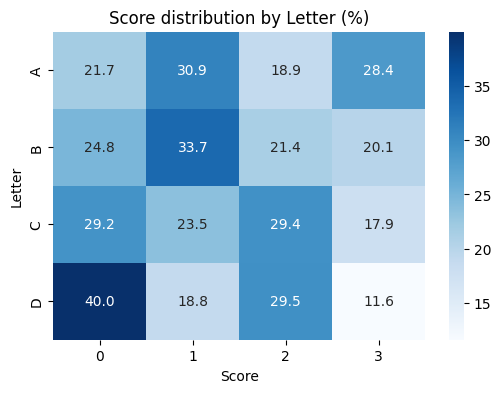

  method_a        method_b   p_value  cramers_v
5   TF-IDF  TF-IDF + GloVe  0.410119   0.020092
3    SBERT          TF-IDF  0.454471   0.018921
1     BERT          TF-IDF  0.690617   0.013869
4    SBERT  TF-IDF + GloVe  0.782572   0.012301
0     BERT           SBERT  0.815597   0.011133
2     BERT  TF-IDF + GloVe  0.934749   0.007581


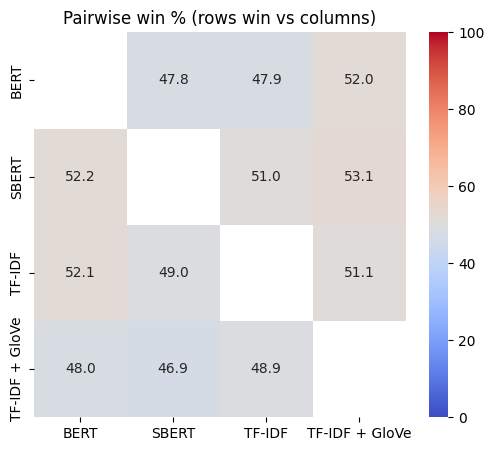

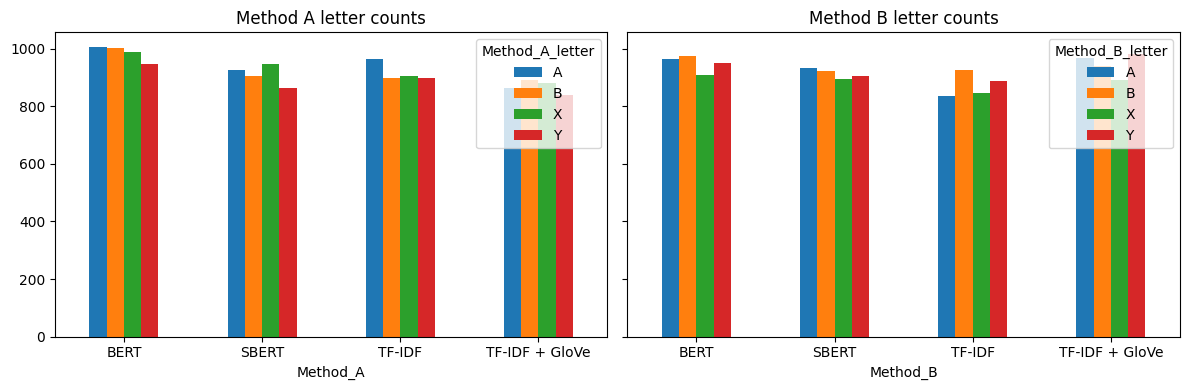

In [112]:
import seaborn as sns
import numpy as np
import itertools
from scipy.stats import chi2_contingency

# Additional analyses & plots you can run quickly (uses existing variables: table, comparisons, counts_A, counts_B)

# 1) Heatmap of score x letter (percentages)
prop_table = table.div(table.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(prop_table, annot=True, fmt=".1f", cmap="Blues", ax=ax)
ax.set_title("Score distribution by Letter (%)")
plt.show()

# 2) Pairwise chi-square + Cramer's V for Method_A letter distributions
methods = counts_A.index.tolist()
pairs = list(itertools.combinations(methods, 2))
results = []
for a, b in pairs:
    sub = pd.concat([counts_A.loc[a], counts_A.loc[b]], axis=1).T
    chi2, p, dof, _ = chi2_contingency(sub)
    n = sub.values.sum()
    r, k = sub.shape
    cramers_v = np.sqrt(chi2 / (n * min(r-1, k-1)))
    results.append((a, b, p, cramers_v))
res_df = pd.DataFrame(results, columns=["method_a","method_b","p_value","cramers_v"]).sort_values("p_value")
print(res_df)

# 3) Win rates per method (when pairwise compared) and heatmap of pairwise win %.
pairs = comparisons.apply(lambda r: tuple(sorted([r.Method_A, r.Method_B])), axis=1)
comparisons["_pair"] = pairs
pair_groups = comparisons.groupby("_pair")
methods = sorted(comparisons.Method_A.unique())
win_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float).fillna(np.nan)
for pair, group in pair_groups:
    m1, m2 = pair
    wins = group["Winner_Method"].value_counts()
    total = len(group)
    win_matrix.loc[m1, m2] = wins.get(m1, 0) / total * 100
    win_matrix.loc[m2, m1] = wins.get(m2, 0) / total * 100

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(win_matrix, annot=True, fmt=".1f", cmap="coolwarm", vmin=0, vmax=100, ax=ax)
ax.set_title("Pairwise win % (rows win vs columns)")
plt.show()

# 4) Quick summary plots: letter distributions for Method_A vs Method_B side-by-side
fig, axes = plt.subplots(1,2, figsize=(12,4), sharey=True)
counts_A.plot(kind="bar", ax=axes[0], rot=0); axes[0].set_title("Method A letter counts")
counts_B.plot(kind="bar", ax=axes[1], rot=0); axes[1].set_title("Method B letter counts")
plt.tight_layout(); plt.show()

# Looking at actual Scores

In [174]:
print(scores.shape)

scores.head()

(1680, 11)


,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Imputed
0,How does the psalmist describe God's compassi...,TF-IDF + GloVe,1,16.0,Bible,79,1For the End concerning things that shall be c...,False,A,0,False
1,How does the psalmist describe God's compassi...,BERT,1,75.36,Bible,18,For the End a psalm by David The heavens decla...,False,B,3,False
2,How does the psalmist describe God's compassi...,SBERT,1,97.46,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,C,2,False
3,How does the psalmist describe God's compassi...,TF-IDF,1,14.64,Psalter,84,"Lord, Thou hast been favourable unto Thy land;...",False,D,1,False
4,How does the psalmist describe God's compassi...,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2,False


In [172]:
pd.pivot_table(data=scores, 
               index='Method', 
               values='Score',
               aggfunc=['mean', 'count'])

,mean,count
,Score,Score
Method,,
BERT,1.645238,420
SBERT,1.550000,420
TF-IDF,1.169048,420
TF-IDF + GloVe,1.738095,420


1.3660391356765278

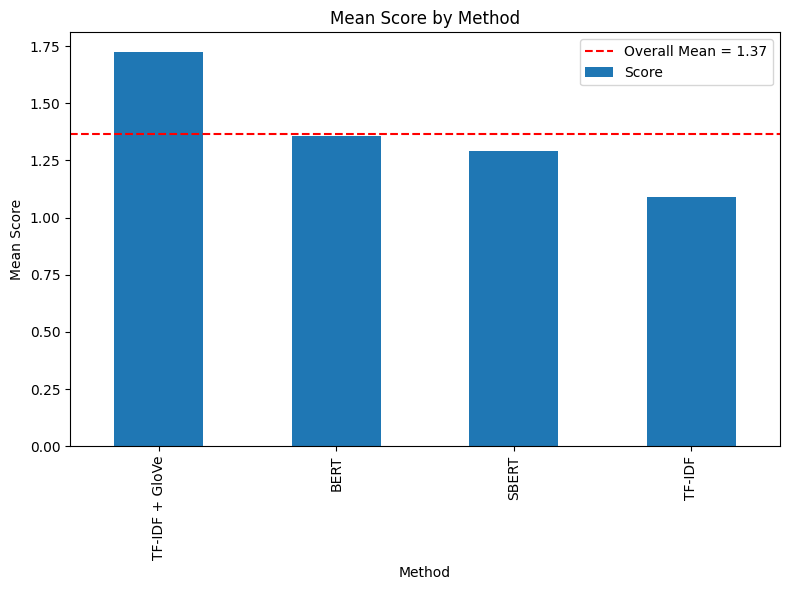

In [34]:
pivot = pd.pivot_table(
    data=scores,
    index="Method",
    values="Score",
    aggfunc="mean"
)

pivot = pivot.sort_values("Score", ascending=False)

ax = pivot.plot(
    kind="bar",
    figsize=(8, 6),
    legend=False
)

ax.axhline(
    y=scores["Score"].mean(),
    color="red",
    linestyle="--",
    label=f"Overall Mean = {scores['Score'].mean():.2f}"
)

plt.ylabel("Mean Score")
plt.title("Mean Score by Method")
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
scores['Method'].unique()

<ArrowStringArray>
['BERT', 'SBERT', 'TF-IDF + GloVe', 'TF-IDF']
Length: 4, dtype: str

In [65]:
# Define a color-blind-friendly palette
color_blind_palette = {
    "BERT": "#0072B2",          # blue
    "SBERT": "#009E73",         # green
    "TF-IDF": "#D55E00",        # vermillion
    "TF-IDF + GloVe": "#CC79A7" # magenta
}

colors = [color_blind_palette[method] for method in pivot.index]

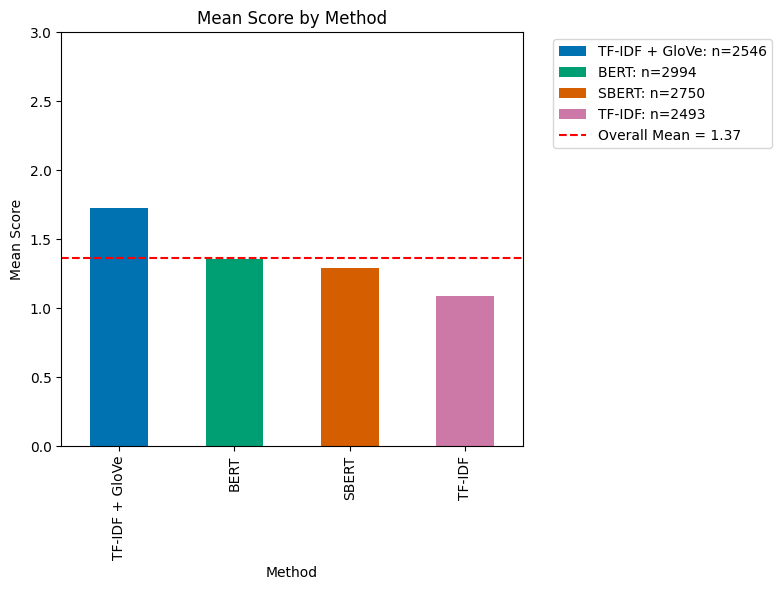

In [107]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

pivot = pd.pivot_table(
    data=scores,
    index="Method",
    values="Score",
    aggfunc=["mean", "count"]
)

pivot.columns = ["Mean Score", "Count"]
pivot = pivot.sort_values("Mean Score", ascending=False)

# Assign a distinct color to each method based on count
cmap = plt.cm.viridis
norm = plt.Normalize(
    pivot["Count"].min(),
    pivot["Count"].max()
)

#colors = cmap(norm(pivot["Count"]))

fig, ax = plt.subplots(figsize=(8, 6))

pivot["Mean Score"].plot(
    kind="bar",
    ax=ax,
    color=colors
)

ax.axhline(
    y=scores["Score"].mean(),
    color="red",
    linestyle="--",
    label=f"Overall Mean = {scores['Score'].mean():.2f}"
)

ax.set_ylabel("Mean Score")
ax.set_title("Mean Score by Method")

# Create legend entries showing count for each bar
count_legend = [
    Patch(
        facecolor=colors[i],
        label=f"{method}: n={pivot['Count'].iloc[i]}"
    )
    for i, method in enumerate(pivot.index)
]

plt.ylim(0,3)

ax.legend(
    handles=[*count_legend, ax.lines[0]],
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

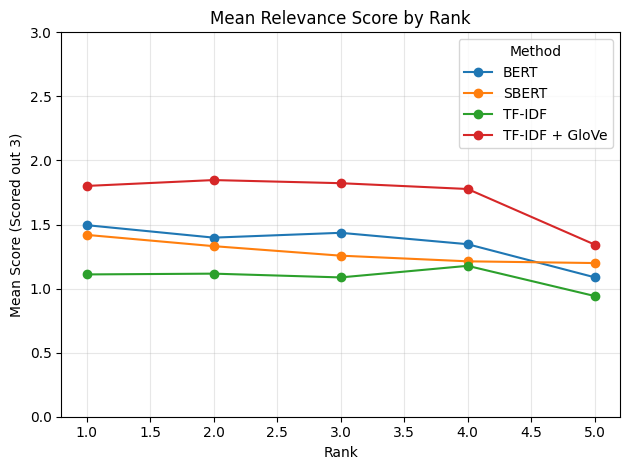

In [39]:
pivoted = pd.pivot_table(
    data=scores,
    index=["Method", "Rank"],
    values="Score",
    aggfunc="mean"
).reset_index()

import matplotlib.pyplot as plt

for method in pivoted["Method"].unique():
    subset = pivoted[pivoted["Method"] == method]

    plt.plot(
        subset["Rank"],
        subset["Score"],
        marker="o",
        label=method
    )
    
plt.ylim(0, 3)

plt.xlabel("Rank")
plt.ylabel("Mean Score (Scored out 3)")
plt.title("Mean Relevance Score by Rank")
plt.legend(title="Method")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

no lines between them because there is niot data on them. 

## Precision@k
Treat scores ≥ 2 as relevant.

In [109]:
scores["Relevant"] = scores["Score"] >= 2

scores.head()

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Query Category,Relevant
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1,Short Keyword,False
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0,Short Keyword,False
2,creation,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2,Short Keyword,True
3,creation,BERT,2,40.51,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,B,1,Short Keyword,False
4,creation,SBERT,2,96.40,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,C,3,Short Keyword,True


* What proportion of retrieved passages are relevant?
* Which method retrieves useful results most consistently?

In [110]:
relevance_summary = (
    scores.groupby("Method")["Relevant"]
    .agg(["mean", "count", "sum"])
    .rename(columns={
        "mean": "relevance_rate",
        "count": "total_results",
        "sum": "relevant_results"
    })
)

relevance_summary

,relevance_rate,total_results,relevant_results
Method,,,
BERT,0.415832,2994,1245
SBERT,0.425455,2750,1170
TF-IDF,0.396711,2493,989
TF-IDF + GloVe,0.546740,2546,1392


In [111]:
import pandas as pd
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    scores["Method"],
    scores["Relevant"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 144.824
p-value: 0.0000
Degrees of freedom: 3


Those results indicate a **very strong statistical signal** that relevance is not distributed equally across retrieval methods.

The P-Value is pretty much zero `p < 0.001`, this means that the null hypothesis has been rejected. This means that there is a retrival method that is producing a signifigantly different porportion of relevance that the other methods. 

In [42]:
scores.groupby("Method")["Relevant"].mean()

Method
BERT              0.415832
SBERT             0.425455
TF-IDF            0.396711
TF-IDF + GloVe    0.546740
Name: Relevant, dtype: float64

* **TF-IDF + GloVe** achieved the highest relevance rate (**54.7%**), indicating that it returned relevant passages more frequently than the other retrieval methods.
* **SBERT** ranked second with a relevance rate of **42.5%**, followed closely by **BERT** at **41.6%**.
* **TF-IDF** produced the lowest relevance rate (**39.7%**), suggesting that it was less effective at retrieving relevant passages overall.
* The improvement of **TF-IDF + GloVe** over standard **TF-IDF** suggests that incorporating semantic word embeddings helped identify relevant passages that keyword matching alone may have missed.
* While **BERT** and **SBERT** outperformed traditional TF-IDF, their relevance rates remained substantially below that of **TF-IDF + GloVe** in this evaluation.
* Overall, these results suggest that **TF-IDF + GloVe was the most effective retrieval approach** among the methods tested when relevance is defined as a score of 2 or higher.


## Looking back at results from Human Annotators

<p align="center">
    <img src="human_algorithm_avgs.png" width="500">
</p>

### Aligning Human and LLM Evaluations

To ensure a fair comparison between human and LLM relevance scores, the analysis will be restricted to the subset of queries evaluated by the human annotators. The LLM evaluated a larger set of queries than the human reviewers, so including all LLM-scored queries would introduce an imbalance in the comparison. By filtering the LLM results to only those queries that were also assessed by humans, both evaluation methods are compared on the same set of retrieval tasks. This allows differences in scores to be attributed to the evaluators themselves rather than differences in the underlying query set.

In [58]:
# Queries seen by both Humans and annotators
# psalm_queries.py (you can save this to import later)
queries = {
    "mercy": "Simple Keyword Queries",
    "prayer": "Simple Keyword Queries",    
    "The Lord is my shepherd": "Phrase/Exact Match Queries",
    "Create in me a clean heart": "Phrase/Exact Match Queries",
    "protection from enemies": "Thematic/Semantic Queries",
    "praise in times of suffering": "Thematic/Semantic Queries",
    "How does the psalmist express trust in God while surrounded by fear and uncertainty?":
        "Long/Complex Queries",
    "Verses where the psalmist remembers past deliverance and uses it to find hope in present trials.":
        "Long/Complex Queries",
    "Rejoice, O ye heavens, sound the trumpets, ye foundation of the earth, thunder forth gladness, O ye mountains: for behold, Emanuel to the Cross our sins, and the Giver of Life hath slain death, raising up Adam; for He loveth mankind.":
        "Orthodox Service Quotes",
    "Have mercy on me, O God, have mercy on me. For my soul trusts in Thee, and in the shadow of Thy wings will I hope, until iniquity pass away.":
        "Orthodox Service Quotes",
    "For the Peace of the world": "Orthodox Service Quotes"
}
import pandas as pd

queries_df = (
    pd.DataFrame(
        queries.items(),
        columns=["Query", "Category"]
    )
)

queries_df

,Query,Category
0,mercy,Simple Keyword Queries
1,prayer,Simple Keyword Queries
2,The Lord is my shepherd,Phrase/Exact Match Queries
3,Create in me a clean heart,Phrase/Exact Match Queries
4,protection from enemies,Thematic/Semantic Queries
5,praise in times of suffering,Thematic/Semantic Queries
6,How does the psalmist express trust in God whi...,Long/Complex Queries
7,Verses where the psalmist remembers past deliv...,Long/Complex Queries
8,"Rejoice, O ye heavens, sound the trumpets, ye ...",Orthodox Service Quotes
9,"Have mercy on me, O God, have mercy on me. For...",Orthodox Service Quotes


Comparing on Queries seen by both human annotators and the LLM to get a sense ofhow the llm compares to Orthodox Christian Evaluators. 

In [64]:
filtered_scores = scores[
    scores["Query"].isin(queries_df["Query"])
]

In [63]:
print("Original rows:", len(scores))
print("Filtered rows:", len(filtered_scores))

filtered_scores["Query"].nunique()

Original rows: 10783
Filtered rows: 1225


10

In [72]:
color_blind_palette = {
    "BERT": "#0072B2",
    "SBERT": "#009E73",
    "TF-IDF": "#D55E00",
    "TF-IDF + GloVe": "#CC79A7"
}

colors = [color_blind_palette[m] for m in pivot.index]

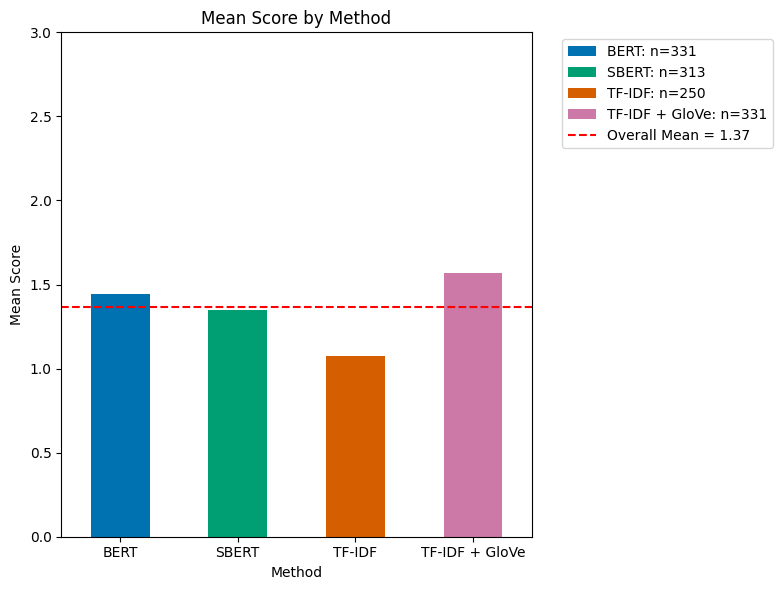

In [74]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

pivot = pd.pivot_table(
    data=filtered_scores,
    index="Method",
    values="Score",
    aggfunc=["mean", "count"]
)

desired_order = [
    "BERT",
    "SBERT",
    "TF-IDF",
    "TF-IDF + GloVe"
]

pivot = pivot.reindex(desired_order)

pivot.columns = ["Mean Score", "Count"]
# pivot = pivot.sort_values("Mean Score", ascending=False)

# Assign a distinct color to each method based on count
cmap = plt.cm.viridis
norm = plt.Normalize(
    pivot["Count"].min(),
    pivot["Count"].max()
)

# colors = cmap(norm(pivot["Count"]))

fig, ax = plt.subplots(figsize=(8, 6))

pivot["Mean Score"].plot(
    kind="bar",
    ax=ax,
    color=colors
)

ax.axhline(
    y=scores["Score"].mean(),
    color="red",
    linestyle="--",
    label=f"Overall Mean = {scores['Score'].mean():.2f}"
)

ax.set_ylabel("Mean Score")
ax.set_title("Mean Score by Method")

# Create legend entries showing count for each bar
count_legend = [
    Patch(
        facecolor=colors[i],
        label=f"{method}: n={pivot['Count'].iloc[i]}"
    )
    for i, method in enumerate(pivot.index)
]

plt.ylim(0,3)
plt.xticks(rotation=0)

ax.legend(
    handles=[*count_legend, ax.lines[0]],
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

3 out 4 stay on the same line 

<p align="center">
    <img src="human_algorithm_avgs.png" width="500">
</p>

# Looking at Query Categories

In [87]:
queries = pd.read_csv('queries.csv')
queries.iloc[:, :2]

,Query Category,Query
0,Phrase / Exact Match,Create in me a clean heart
1,Orthodox Serivce Quotes,For the Peace of the world
2,Orthodox Serivce Quotes,"Have mercy on me, O God, have mercy on me. For..."
3,Long / Complex,How does the psalmist express trust in God whi...
4,Short Keyword,mercy
...,...,...
79,Thematic / Semantic,Psalms about trusting God after betrayal
80,Long / Complex,I fall into the same sin contiously need help ...
81,Long / Complex,How does the psalmist describe God's compassi...
82,Phrase / Exact Match,valley of the shadow of death


In [88]:
scores.head()

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0
2,creation,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2
3,creation,BERT,2,40.51,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,B,1
4,creation,SBERT,2,96.40,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,C,3


In [91]:
scores["Query Category"] = scores["Query"].map(
    queries.set_index("Query")["Query Category"]
)

scores.head()

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Query Category
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1,Short Keyword
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0,Short Keyword
2,creation,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2,Short Keyword
3,creation,BERT,2,40.51,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,B,1,Short Keyword
4,creation,SBERT,2,96.40,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,C,3,Short Keyword


In [97]:
pivot = pd.pivot_table(data=scores, 
               index='Method', 
               values='Score',
               aggfunc=['mean', 'count'])
pivot

,mean,count
,Score,Score
Method,,
BERT,1.357381,2994
SBERT,1.293091,2750
TF-IDF,1.091456,2493
TF-IDF + GloVe,1.723881,2546


In [96]:
pivot.loc[[pivot[("mean", "Score")].idxmax()]]

,mean,count
,Score,Score
Method,,
TF-IDF + GloVe,1.723881,2546


In [94]:
avg_highest = (
    scores
    .groupby(["Method", "Query"])["Score"]
    .max()
    .groupby("Method")
    .mean()
)

print(avg_highest)

Method
BERT              2.857143
SBERT             2.880952
TF-IDF            2.714286
TF-IDF + GloVe    2.987342
Name: Score, dtype: float64


In [100]:
pd.pivot_table(data=scores, 
               index=['Query Category'], 
               values='Score', 
               aggfunc='mean')

,Score
Query Category,
Long / Complex,1.455146
Orthodox Serivce Quotes,1.462164
Phrase / Exact Match,1.452031
Short Keyword,1.174063
Thematic / Semantic,1.414384


In [103]:
pd.pivot_table(data=scores, 
               index=['Query Category', 'Letter'], 
               values='Score', 
               aggfunc='mean')

Score
Query Category          Letter          
Long / Complex          A       1.701818
                        B       1.381818
                        C       1.524904
                        D       1.189516
Orthodox Serivce Quotes A       1.874603
                        B       1.528571
                        C       1.307937
                        D       1.102113
Phrase / Exact Match    A       1.733668
                        B       1.492462
                        C       1.375209
                        D       1.172084
Short Keyword           A       1.199057
                        B       1.107322
                        C       1.298954
                        D       1.082278
Thematic / Semantic     A       1.520518
                        B       1.544276
                        C       1.406048
                        D       1.123967